# Import Libraries

In [77]:
import pandas as pd
import numpy as np
import boto3
import s3fs
import matplotlib.pyplot as plt
import seaborn as sns
# Weather data library
from meteostat import Stations, Daily
from datetime import datetime
from pyathena import connect
import warnings
warnings.filterwarnings("ignore")

# Connect SageMaker to S3

In [78]:
#Create S3 client using boto3
#This allows the notebook to communicate with S3
s3 = boto3.client('s3')

#Define your S3 bucket name where your datasets are stored
bucket = "vegetation-risk-ml"

#list files inside bucket
response = s3.list_objects_v2(Bucket=bucket)

#Print the names of the files in the bucket
for obj in response['Contents']:
    print(obj['Key'])

athena-results/
processed/
processed/fire/fire_cleaned.csv
processed/forest/combined_forest_data.csv
processed/forest/forest_cleaned.csv
processed/weather/weather_cleaned.csv
raw/
raw/fire/
raw/fire/California_Historic_Fire_data.csv
raw/forest/
raw/forest/CA_PLOT.csv
raw/forest/CA_SUBPLOT.csv
raw/forest/CA_TREE.csv
raw/forest/CA_TREE_REGIONAL_BIOMASS.csv
raw/weather/
raw/weather/california_weather_data.csv


# **DATA PREPARATION**

**Define s3 path**

In [79]:
#Define S3 fi
forest_path  = "s3://vegetation-risk-ml/processed/forest/combined_forest_data.csv"
fire_path    = "s3://vegetation-risk-ml/raw/fire/California_Historic_Fire_data.csv"
weather_path = "s3://vegetation-risk-ml/raw/weather/california_weather_data.csv"

**Load datasets**

In [80]:
combined_forest = pd.read_csv(forest_path, low_memory=False)
print("Forest dataset shape :", combined_forest.shape)
fire = pd.read_csv(fire_path, low_memory=False)
print("Fire dataset shape :", fire.shape)
weather = pd.read_csv(weather_path, low_memory=False)
print("Weather dataset shape :", weather.shape)

print("Datasets loaded successfully")

Forest dataset shape : (1687167, 14)
Fire dataset shape : (3372, 23)
Weather dataset shape : (309116, 10)
Datasets loaded successfully


# DATA CLEANING AND PREPROCESSING

### Forest dataset cleaning

We will handle missing values and drop the unnecessary columns so that the dataset represents only relevent columns which directly affects trimming prioritization.This stage will prepare our dataset for integration.

Here only variables that influence vegetation density and wildfire potential are retained.

**Drop unnecessary columns**

 We drop plt_cn,spsd to avoid noise in the data and reduce memory usage.From exploration,we know that REGIONAL_DRYBIOT and REGIONAL_DRYBIOM are highly correlated so we keep only one of them.

In [81]:
#select most relevent column 
combined_forest=combined_forest[["DIA", "HT", "SLOPE", "REGIONAL_DRYBIOT","LAT", "LON","COUNTYCD"]]  #tree size,height,terrain,direction,biomass

#check the shape of the dataset
combined_forest.shape

(1687167, 7)

**Remove Duplicates**

In [82]:
#remove duplicates
combined_forest = combined_forest.drop_duplicates()
# Verify
print("Duplicates remaining:", combined_forest.duplicated().sum())

Duplicates remaining: 0


**Handle missing valus**

To handle missing values, median is used because biomass is skewed and avoids distortion from outliers.

In [83]:
#fill missing values for biomass
combined_forest = combined_forest.dropna(subset=["LAT", "LON"])
combined_forest["REGIONAL_DRYBIOT"] = combined_forest["REGIONAL_DRYBIOT"].fillna(combined_forest["REGIONAL_DRYBIOT"].median())
combined_forest["SLOPE"] = combined_forest["SLOPE"].fillna(combined_forest["SLOPE"].median())
combined_forest["DIA"] = combined_forest["DIA"].fillna(combined_forest["DIA"].median()) 
combined_forest["HT"] = combined_forest["HT"].fillna(combined_forest["HT"].median())                                                     

# Verify
print("Missing values:\n", combined_forest.isnull().sum())

Missing values:
 DIA                 0
HT                  0
SLOPE               0
REGIONAL_DRYBIOT    0
LAT                 0
LON                 0
COUNTYCD            0
dtype: int64


**Handle outlier**

In [84]:
#handle unrealistic value of tree diameter and height
combined_forest = combined_forest[(combined_forest["DIA"] > 0) & (combined_forest["HT"] > 0)]

In [85]:
#Verify the resulting dataset
combined_forest.head()

,DIA,HT,SLOPE,REGIONAL_DRYBIOT,LAT,LON,COUNTYCD
0,3.9,43.0,50.0,404.669221,41.478172,-123.946777,15
1,3.9,43.0,60.0,404.669221,41.478172,-123.946777,15
2,3.9,43.0,40.0,404.669221,41.478172,-123.946777,15
3,24.1,95.0,50.0,404.669221,41.478172,-123.946777,15
4,24.1,95.0,60.0,404.669221,41.478172,-123.946777,15


### Fire dataset cleaning

Here we will keep valid geographic coordinates and meaningful fire size measurements only.

**Select Relevent Columns**

In [86]:
#select relevant features only
fire=fire[["incident_acres_burned", "incident_longitude", "incident_latitude", "incident_date_created","incident_county"]]

In [87]:
#remove fires with invalid coordinates (outside California)
fire = fire[(fire["incident_latitude"].between(32, 42)) &(fire["incident_longitude"].between(-124, -114))]

#Remove fires with missing coordinates
fire = fire.dropna(subset=["incident_latitude", "incident_longitude"])

#Remove fires with zero size
fire = fire[fire["incident_acres_burned"] > 0]

#Convert datecolumn to datetime and remove timezone
fire["incident_date_created"] = pd.to_datetime(fire["incident_date_created"], errors="coerce").dt.date

# Remove missing county
fire = fire.dropna(subset=["incident_county", "incident_date_created"])

# Reset index
fire = fire.reset_index(drop=True)

#display results
print("Cleaned fire dataset shape:", fire.shape)


Cleaned fire dataset shape: (3253, 5)


In [88]:
#check for any remaining missing value
print(fire.isnull().sum())
fire.head()

incident_acres_burned    0
incident_longitude       0
incident_latitude        0
incident_date_created    0
incident_county          0
dtype: int64


,incident_acres_burned,incident_longitude,incident_latitude,incident_date_created,incident_county
0,37.0,-122.309000,40.774000,2017-10-31,Shasta
1,407.0,-118.016510,36.602575,2013-02-24,Inyo
2,30.0,-116.941311,34.288877,2013-04-20,San Bernardino
3,274.0,-119.635004,37.116295,2013-04-30,Madera
4,6896.0,-121.595555,40.190062,2013-05-01,Tehama


#### Weather dataset cleaning

We will select temperature ,precipitation and wind speed that influence vegetation growth and fire risk. Here missing values are imputed to ensure consistent weather observations.

In [89]:

# Fill missing rainfall
weather["prcp"] = weather["prcp"].fillna(0)

# Fill wind speed
weather["wspd"] = weather["wspd"].fillna(weather["wspd"].median())

# Remove unrealistic temperatures
weather = weather[(weather["tavg"] > -40) & (weather["tavg"] < 60)]

# Fill missing average temperature
weather["tavg"] = weather["tavg"].fillna((weather["tmin"] + weather["tmax"])/2)

# We can drop tmax and tmin as we have tavg, and they are highly correlated
#also we will drop pressure because of week correlation
weather = weather[['time','tavg', 'prcp', 'wspd', 'station', 'lat', 'lon']]

In [90]:
#Verify the resulting dataset
print("Cleaned weather dataset shape:", weather.shape)
#check for any remaining missing values
print("Missing values in each column:")
print(weather.isnull().sum())
print("First few rows of the cleaned dataset:")
weather.head()

Cleaned weather dataset shape: (301803, 7)
Missing values in each column:
time       0
tavg       0
prcp       0
wspd       0
station    0
lat        0
lon        0
dtype: int64
First few rows of the cleaned dataset:


,time,tavg,prcp,wspd,station,lat,lon
0,2020-11-05,13.5,0.0,9.4,69007,36.6815,-121.7617
1,2020-11-06,12.1,0.0,9.4,69007,36.6815,-121.7617
2,2020-11-07,9.9,0.0,9.4,69007,36.6815,-121.7617
3,2020-11-08,9.1,0.0,9.4,69007,36.6815,-121.7617
4,2020-11-09,5.5,0.0,9.4,69007,36.6815,-121.7617


#### **Save the cleaned dataset to S3**

The cleaned datasets are then store back in S3 in separete folder processed/ for future analysis.

In [91]:
combined_forest.to_csv("s3://vegetation-risk-ml/processed/forest/forest_cleaned.csv",index=False)

fire.to_csv("s3://vegetation-risk-ml/processed/fire/fire_cleaned.csv",index=False)

weather.to_csv("s3://vegetation-risk-ml/processed/weather/weather_cleaned.csv",index=False)

print("Cleaned datasets saved successfully in S3")

Cleaned datasets saved successfully in S3


Next,to merge all three cleaned datasets, we are using Athena.

Athena is used to perform  data merging of all three cleaned datasets and aggregation directly on S3 without loading large datasets into memory.This resolves the high memory usage and slow processing.The final unified feature table will be used for model training and dashboard visualization.

# Connect SageMaker to Athena

In [106]:
#Create folfer in S3 to save athena results
s3 = boto3.client("s3")

s3.put_object(Bucket="vegetation-risk-ml",Key="athena-results/")
print("athena-results folder created in S3")

athena-results folder created in S3


In [107]:
#verify the athena results folder is created
response = s3.list_objects_v2(Bucket="vegetation-risk-ml",Prefix="athena-results/")
print("Folder exists:", "athena-results/" in [obj["Key"] for obj in response.get("Contents", [])])

Folder exists: True


In [108]:

#Query results are stored in s3 in this directory
s3_staging_dir = "s3://vegetation-risk-ml/athena-results/"

# Athena connection
conn = connect(s3_staging_dir=s3_staging_dir,region_name="us-east-1")

print("Connected to Athena")

Connected to Athena


# Create Table for Forest Dataset

In [109]:
#drop old tables if exist
drop_query = """
DROP TABLE IF EXISTS vegetation_ml.forest_cleaned
"""
pd.read_sql(drop_query, conn)
print("Old table dropped if any")

Old table dropped if any


In [110]:
#create forest table
forest_query = """
CREATE EXTERNAL TABLE IF NOT EXISTS vegetation_ml.forest_cleaned (
    DIA DOUBLE,
    HT DOUBLE,
    SLOPE DOUBLE,
    REGIONAL_DRYBIOT DOUBLE,
    LAT DOUBLE,
    LON DOUBLE,
    COUNTYCD INT
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
LOCATION 's3://vegetation-risk-ml/processed/forest/'
TBLPROPERTIES ("skip.header.line.count"="1","use.null.for.invalid.data"="true");
"""

pd.read_sql(forest_query, conn)
print("Forest table created successfully")

Forest table created successfully


# Create Table for Weather Dataset

In [111]:
#drop if table already exists
drop_query = """
DROP TABLE IF EXISTS vegetation_ml.weather_cleaned
"""
pd.read_sql(drop_query, conn)
print("Old table dropped")

Old table dropped


In [112]:
weather_query = """
CREATE EXTERNAL TABLE IF NOT EXISTS vegetation_ml.weather_cleaned (
    time STRING,
    tavg DOUBLE,
    prcp DOUBLE,
    wspd DOUBLE,
    station STRING,
    lat DOUBLE,
    lon DOUBLE
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
LOCATION 's3://vegetation-risk-ml/processed/weather/'
TBLPROPERTIES ("skip.header.line.count"="1","use.null.for.invalid.data"="true");
"""
pd.read_sql(weather_query, conn)
print("Weather table created successfully")


Weather table created successfully


# Create Table for Fire Dataset

In [113]:
#drop if table exists
drop_query = """
DROP TABLE IF EXISTS vegetation_ml.fire_cleaned
"""
pd.read_sql(drop_query, conn)

""


In [114]:
fire_query = """
CREATE EXTERNAL TABLE IF NOT EXISTS vegetation_ml.fire_cleaned (
    incident_acres_burned DOUBLE,
    incident_longitude DOUBLE,
    incident_latitude DOUBLE,
    incident_date_created STRING,
    incident_county STRING
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
LOCATION 's3://vegetation-risk-ml/processed/fire/'
TBLPROPERTIES ("skip.header.line.count"="1","use.null.for.invalid.data"="true");
"""
pd.read_sql(fire_query, conn)
print("Fire table created successfully")

Fire table created successfully


**Verify tables**

In [115]:

# Check if tables exist and data is accessible
for table in ["forest_cleaned", "weather_cleaned", "fire_cleaned"]:
    query = f"SELECT * FROM vegetation_ml.{table} LIMIT 5"
    df = pd.read_sql(query, conn)
    print(f"Sample data from {table}:")
    print(df.head())
    print("\n")

Sample data from forest_cleaned:
    dia    ht  slope  regional_drybiot        lat         lon  countycd
0   3.9  43.0   50.0        404.669221  41.478172 -123.946777        15
1   3.9  43.0   60.0        404.669221  41.478172 -123.946777        15
2   3.9  43.0   40.0        404.669221  41.478172 -123.946777        15
3  24.1  95.0   50.0        404.669221  41.478172 -123.946777        15
4  24.1  95.0   60.0        404.669221  41.478172 -123.946777        15


Sample data from weather_cleaned:
         time  tavg  prcp  wspd station      lat       lon
0  2020-11-05  13.5   0.0   9.4   69007  36.6815 -121.7617
1  2020-11-06  12.1   0.0   9.4   69007  36.6815 -121.7617
2  2020-11-07   9.9   0.0   9.4   69007  36.6815 -121.7617
3  2020-11-08   9.1   0.0   9.4   69007  36.6815 -121.7617
4  2020-11-09   5.5   0.0   9.4   69007  36.6815 -121.7617


Sample data from fire_cleaned:
   incident_acres_burned  incident_longitude  incident_latitude  \
0                   37.0         -122.309000 

# Create Unified Feature table in Athena

Now we create the final Feature table by merging all three tables. This final table becomes the single source of truth for modelling and dashboard analysis.

The three tables are then merged in Athena by first aggregating fire incidents to the county level and calculating county centroids. Weather stations were then joined to these centroids using spatial proximity join, and each forest tree was matched to its nearest county centroid. This creates a unified dataset where every tree record has associated county-level fire statistics and weather data from nearby stations.

In [116]:
drop_query = "DROP TABLE IF EXISTS vegetation_ml.vegetation_risk_dataset"
pd.read_sql(drop_query, conn)

""


In [117]:
create_query = """
CREATE TABLE vegetation_ml.vegetation_risk_dataset
WITH (
    format='PARQUET',
    external_location='s3://vegetation-risk-ml/final/'
) AS

WITH county_fire AS (
    SELECT
        TRIM(SPLIT_PART(incident_county, ',', 1)) AS incident_county,
        COUNT(*) AS fire_count,
        MAX(incident_acres_burned) AS max_fire_size,
        AVG(incident_acres_burned) AS avg_fire_size,
        AVG(incident_latitude) AS fire_lat,
        AVG(incident_longitude) AS fire_lon,
        YEAR(MAX(DATE_PARSE(incident_date_created,'%Y-%m-%d'))) AS fire_year,
        MONTH(MAX(DATE_PARSE(incident_date_created,'%Y-%m-%d'))) AS fire_month
    FROM vegetation_ml.fire_cleaned
    WHERE incident_county IS NOT NULL
      AND incident_date_created IS NOT NULL
      AND DATE_PARSE(incident_date_created,'%Y-%m-%d')
          BETWEEN DATE '2000-01-01' AND DATE '2024-12-31'
    GROUP BY TRIM(SPLIT_PART(incident_county, ',', 1))
),

weather_grid AS (
    SELECT
        ROUND(lat, 1) AS lat_bin,
        ROUND(lon, 1) AS lon_bin,
        AVG(tavg) AS avg_temp,
        AVG(prcp) AS avg_rain,
        AVG(wspd) AS avg_wind
    FROM vegetation_ml.weather_cleaned
    GROUP BY ROUND(lat, 1), ROUND(lon, 1)
),

forest_matched AS (
    SELECT
        f.DIA, f.HT, f.SLOPE, f.REGIONAL_DRYBIOT,
        f.LAT, f.LON, f.COUNTYCD,

        cf.incident_county,
        cf.fire_count,
        cf.max_fire_size,
        cf.avg_fire_size,
        cf.fire_year,
        cf.fire_month,

        wg.avg_temp,
        wg.avg_rain,
        wg.avg_wind,

        ROW_NUMBER() OVER (
            PARTITION BY f.LAT, f.LON, f.DIA, f.HT
            ORDER BY
                POWER(f.LAT - cf.fire_lat, 2) +
                POWER(f.LON - cf.fire_lon, 2)
        ) AS rn

    FROM vegetation_ml.forest_cleaned f

    LEFT JOIN county_fire cf
        ON  f.LAT BETWEEN cf.fire_lat - 1.0 AND cf.fire_lat + 1.0
        AND f.LON BETWEEN cf.fire_lon - 1.0 AND cf.fire_lon + 1.0

    LEFT JOIN weather_grid wg
        ON ROUND(f.LAT, 1) = wg.lat_bin
        AND ROUND(f.LON, 1) = wg.lon_bin
)

SELECT
    DIA, HT, SLOPE, REGIONAL_DRYBIOT,
    LAT, LON, COUNTYCD,

    COALESCE(incident_county, 'Unknown') AS incident_county,
    COALESCE(fire_count, 0) AS fire_count,
    COALESCE(max_fire_size, 0) AS max_fire_size,
    COALESCE(avg_fire_size, 0) AS avg_fire_size,
    COALESCE(fire_year, 0) AS fire_year,
    COALESCE(fire_month, 0) AS fire_month,

    COALESCE(avg_temp, 15) AS avg_temp,
    COALESCE(avg_rain, 0.5) AS avg_rain,
    COALESCE(avg_wind, 5) AS avg_wind

FROM forest_matched
WHERE rn = 1
"""
pd.read_sql(create_query, conn)
print("Unified feature table created successfully")

Unified feature table created successfully


In [124]:
county_query = """
SELECT DISTINCT incident_county, fire_count, fire_year, fire_month
FROM vegetation_ml.vegetation_risk_dataset
ORDER BY incident_county LIMIT 20
"""
print(pd.read_sql(county_query, conn))

   incident_county  fire_count  fire_year  fire_month
0          Alameda          48       2024          10
1           Alpine           2       2021           7
2           Amador          21       2024          11
3            Butte          93       2024           9
4        Calaveras          42       2024          11
5           Colusa          13       2024          10
6     Contra Costa          44       2024           9
7        Del Norte           3       2023           8
8        El Dorado          51       2024           9
9           Fresno         121       2024          12
10           Glenn          14       2024          10
11        Humboldt          34       2024          10
12        Imperial           2       2024           6
13            Inyo          18       2024          11
14            Kern         149       2024          12
15           Kings          14       2024          11
16            Lake          55       2024          10
17          Lassen          

In [125]:
weather_check = """
SELECT COUNT(*) AS total_stations,MIN(lat) AS min_lat, MAX(lat) AS max_lat,MIN(lon) AS min_lon, MAX(lon) AS max_lon
FROM vegetation_ml.weather_cleaned
"""
print(pd.read_sql(weather_check, conn))

   total_stations  min_lat  max_lat   min_lon   max_lon
0          301803  32.6167  41.7802 -124.2365 -114.6233


In [126]:
fire_check = """
SELECT DISTINCT incident_county
FROM vegetation_ml.fire_cleaned
ORDER BY incident_county
LIMIT 20
"""
print(pd.read_sql(fire_check, conn))


                                 incident_county
0                                        Alameda
1                           Alameda, San Joaquin
2                                         Alpine
3                                         Amador
4                              Amador, Calaveras
5                              Amador, El Dorado
6                                          Butte
7          Butte, Plumas, Shasta, Lassen, Tehama
8                                  Butte, Tehama
9                                      Calaveras
10  Calaveras, San Joaquin, Stanislaus, Tuolumne
11                                        Colusa
12                                  Colusa, Lake
13                       Colusa, Lake, Mendocino
14                Colusa, Mendocino, Glenn, Lake
15                                  Contra Costa
16                                     Del Norte
17                                     El Dorado
18                     El Dorado, Alpine, Amador
19                  

In [127]:
#Verify the resulting dataset
vegetation_risk_dataset.head()

,dia,ht,slope,regional_drybiot,lat,lon,countycd,incident_county,fire_count,max_fire_size,avg_fire_size,fire_year,fire_month,avg_temp,avg_rain,avg_wind
0,1.4,13.0,40.0,404.669221,41.357502,-123.913048,23,Humboldt,34,50198.0,2761.823529,2024,10,15.0,0.5,5.0
1,1.7,23.0,40.0,404.669221,41.357502,-123.913048,23,Humboldt,34,50198.0,2761.823529,2024,10,15.0,0.5,5.0
2,1.0,20.0,40.0,404.669221,41.357502,-123.913048,23,Humboldt,34,50198.0,2761.823529,2024,10,15.0,0.5,5.0
3,4.6,23.0,40.0,404.669221,41.357502,-123.913048,23,Humboldt,34,50198.0,2761.823529,2024,10,15.0,0.5,5.0
4,28.5,67.0,35.0,404.669221,41.351944,-123.835838,23,Humboldt,34,50198.0,2761.823529,2024,10,15.0,0.5,5.0


**Load Final Feature Table from S3 into SageMaker**

The unified feature table (source of truth) created by Athena is loaded from the S3 final/ folder into SageMaker for feature engineering and model training.

In [128]:
vegetation_risk_data = pd.read_parquet("s3://vegetation-risk-ml/final/")
print("Shape:", vegetation_risk_data.shape)

Shape: (841350, 16)


# **Feature Engineering**

# Feature Creation

Here we will create new features and transform the existing features for our machine learning model.

**Fuel Mositure Risk**

This featutee captures vegetation dryness(hot weather and no rain).The higher value means drier the vegetation condition,which increase wildfire risk if ignition happens. Its calculated as fuel moisture risk=temperatue/(rainfall+1).

Area with high temperature and low rainfall are where dry vegetation accumulates.Such plots need to be trimmed first as a small ignition can trigger large fire.

In [129]:
# Calculate fuel moisture risk as the ratio of average temperature to average rainfall,#=1 to avoid division by zero
vegetation_risk_data["fuel_moisture_risk"] = vegetation_risk_data["avg_temp"] / (vegetation_risk_data["avg_rain"] + 1)
vegetation_risk_data.value_counts("fuel_moisture_risk").head()

fuel_moisture_risk
10.000000    839018
3.877097        485
2.931071        484
4.219319        291
5.057556        203
Name: count, dtype: int64

**Fire Recurrence Risk**

Locations with repeated fire history may require more aggressive vegetation management, as those areas are more likely to burn again. We calculate this by Fire recurrence= number of fires in near location.

In [139]:
# Log transform fire recurrence to compress the right-skewed distribution
vegetation_risk_data["fire_recurrence"] = np.log1p(vegetation_risk_data["fire_count"])
vegetation_risk_data["fire_recurrence"].value_counts().head()

fire_recurrence
0.000000    453038
3.555348     52436
3.784190     44687
4.543295     36425
3.218876     35843
Name: count, dtype: int64

**Vegetation Fuel Load Index**

A dense stand of large, tall trees with high biomass contains far more burnable material than sparse, small shrubs. This index quantifies the total combustible fuel load at each plot by combining tree physical size with biomass.

This measures howmuch burnable vegetation exist. This is measured as Fuel load=tree size*toal biomass

In [138]:
vegetation_risk_data["fuel_load_index"] =np.log1p(vegetation_risk_data["dia"] * vegetation_risk_data["ht"] *(vegetation_risk_data["regional_drybiot"]))
vegetation_risk_data["fuel_load_index"].head()

0     9.404350
1    10.651323
2     9.335363
3     9.544101
4    11.858722
Name: fuel_load_index, dtype: float64

Combines tree size and biomass.Higher value indicates dense vegetation that could act as a wildfirefuel.

**Combined Wildfire Risk Score**

Here we create risk score by combining vegetation fuel load, moisture risk, and fire recurrence.Since fuel load index is high in value and can dominate,we will normalise using min max scaler for finding the fire risk score.

In [135]:
#normalize before combining into wildfire_risk_score
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cols_to_scale = ["fuel_load_index", "fuel_moisture_risk", "fire_recurrence"]
vegetation_risk_data[cols_to_scale] = scaler.fit_transform(vegetation_risk_data[cols_to_scale])

This score becomes the basis for creating the target variable (trim_priority).

In [140]:
vegetation_risk_data["wildfire_risk_score"] = (0.4 * vegetation_risk_data["fuel_load_index"] +0.3 * vegetation_risk_data["fuel_moisture_risk"] +0.3 * vegetation_risk_data["fire_recurrence"])
vegetation_risk_data["wildfire_risk_score"].value_counts().head()

wildfire_risk_score
6.228246    419
6.296899    415
6.483658    358
6.524630    354
6.127304    338
Name: count, dtype: int64

**Create Target Variable**

The final target variable classifies vegetation trimming priority into three categories.The wildfire risk score score feeds directly into pd.qcut to create the Low / Medium / High bins.The classification helps to understand the urgency for trimming.

In [141]:
vegetation_risk_data["trim_priority"] = pd.qcut(vegetation_risk_data["wildfire_risk_score"],q=3,labels=["Low","Medium","High"])

vegetation_risk_data["trim_priority"].value_counts()

trim_priority
Low       266688
Medium    266687
High      266687
Name: count, dtype: int64

# Feature Transformation (log transformation)

To reduce skweness of data we apply log transormation to fire size,biomass 

In [143]:
# Log transform fire size (use correct column name)
vegetation_risk_data["log_fire_size"] = np.log1p(vegetation_risk_data["max_fire_size"])
vegetation_risk_data["log_fire_size"].value_counts().head()

log_fire_size
0.000000     453038
10.823750     50905
12.202868     32128
13.847638     30500
12.315487     23890
Name: count, dtype: int64

The target variable was created using quantile-based binning of the wildfire risk score to ensure balanced class distribution across Low, Medium, and High risk categories.

# Save Final Modeling dataset in S3

In [144]:
vegetation_risk_data.to_parquet("s3://vegetation-risk-ml/final/ml_ready/vegetation_ml_dataset.parquet", index=False)

print("Final ML dataset saved")
print(f"Shape: {vegetation_risk_data.shape}")
print(f"Columns: {list(vegetation_risk_data.columns)}")

Final ML dataset saved
Shape: (841350, 22)
Columns: ['dia', 'ht', 'slope', 'regional_drybiot', 'lat', 'lon', 'countycd', 'incident_county', 'fire_count', 'max_fire_size', 'avg_fire_size', 'fire_year', 'fire_month', 'avg_temp', 'avg_rain', 'avg_wind', 'fuel_moisture_risk', 'fire_recurrence', 'fuel_load_index', 'wildfire_risk_score', 'trim_priority', 'log_fire_size']


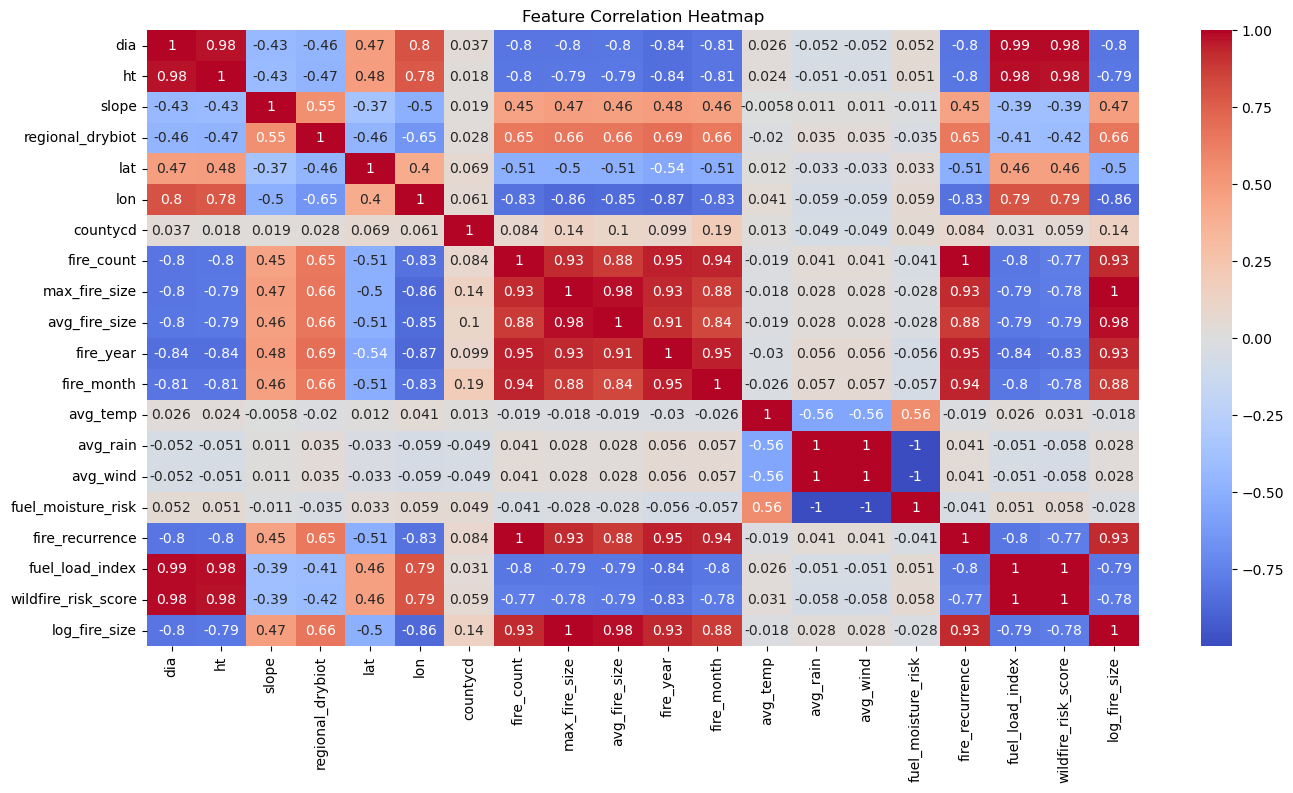

In [147]:
#Visualise the final ML table correlation with each other
corr = vegetation_risk_data.corr(method="spearman", numeric_only=True)

plt.figure(figsize=(16,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

Our feature selection for model training will be based on the Correlation analysis from the plot . Only strong relationships with the target, among derived fire and vegetation features will be retained for training. To avoid multicollinearity and data leakage, redundant variables will be  removed before modeling.